**k-Nearest Neighbors (k-NN)** is a simple, non-parametric, and lazy supervised learning algorithm. It can be used for both classification (predicting a label) and regression

# The Core Intuition

If you want to make a prediction for a new, unknown data point, you look at the k closest data points (neighbors) to it in your dataset.
- For Classification: The new point is assigned the class that is most common among its k nearest neighbors (majority vote).
- For Regression: The new point is assigned the average value of its k nearest neighbors.

# Mathematical Example

**Dataset**

|Point|Feature $x_1$|​Feature $x_2$|​Class Label $(y_{class​})$|Continuous Target $(y_{reg}​)$
|---|---|---|---|---|
|A|1|2|Red|10.0|
|B|2|3|Red|12.0|
|C|3|1|Blue|30.0|
|D|6|5|Blue|45.0|
|E|7|7|Red|50.0|


**Calculate Distances**

- Point A $(1, 2)$: $\sqrt{(3 - 1)^2 + (3 - 2)^2} = \sqrt{2^2 + 1^2} = \sqrt{5} \approx \mathbf{2.24}$
- Point B $(2, 3)$: $\sqrt{(3 - 2)^2 + (3 - 3)^2} = \sqrt{1^2 + 0^2} = \sqrt{1} = \mathbf{1.00}$
- Point C $(3, 1)$: $\sqrt{(3 - 3)^2 + (3 - 1)^2} = \sqrt{0^2 + 2^2} = \sqrt{4} = \mathbf{2.00}$
- Point D $(6, 5)$: $\sqrt{(3 - 6)^2 + (3 - 5)^2} = \sqrt{(-3)^2 + (-2)^2} = \sqrt{13} \approx \mathbf{3.61}$
- Point E $(7, 7)$: $\sqrt{(3 - 7)^2 + (3 - 7)^2} = \sqrt{(-4)^2 + (-4)^2} = \sqrt{32} \approx \mathbf{5.66}$

**Select the $k = 3$ Nearest Neighbors**

Sort distances from smallest to largest and take the top 3:

- Point B (Distance: $1.00$, Class: Red, Target: $12.0$)
- Point C (Distance: $2.00$, Class: Blue, Target: $30.0$)
- Point A (Distance: $2.24$, Class: Red, Target: $10.0$)

**How the Point is Classified (Majority Vote)**

Count the occurrences of each class within the 3 nearest neighbors (Point B, C, A):

- Red: 2 votes (Points B and A)
- Blue: 1 vote (Point C)

Compute posterior class probabilities:

$$P(Y = \text{Red} \mid q) = \frac{2}{3} \approx 0.67$$
$$P(Y = \text{Blue} \mid q) = \frac{1}{3} \approx 0.33$$

Final Classification: $\hat{y} = \mathbf{\text{Red}}$

**How the Point is Regressified (Standard & Weighted)**

1. **Unweighted Average (Standard KNN Regression)**
    
    Take the simple mean of the neighbor target values ($12.0, 30.0, 10.0$):
    $$\hat{y} = \frac{12.0 + 30.0 + 10.0}{3} = \frac{52.0}{3} = \mathbf{17.33}$$

2. **Distance-Weighted Average (Weighted KNN Regression)**

    Assign weights inverse to their distance $w_j = \frac{1}{d_j}$:
    - $w_B = \frac{1}{1.00} = 1.000$
    - $w_C = \frac{1}{2.00} = 0.500$
    - $w_A = \frac{1}{2.24} = 0.446$
    
    Sum of weights $\sum w = 1.000 + 0.500 + 0.446 = 1.946$
    
    $$\hat{y}_{\text{weighted}} = \frac{(1.000 \times 12.0) + (0.500 \times 30.0) + (0.446 \times 10.0)}{1.946} = \frac{31.46}{1.946} = \mathbf{16.17}$$


# Python Implementation

In [9]:
import numpy as np

class KNearestNeighbors:
    def __init__(self, k=5, task='classification', weights='uniform'):
        """
        k: int, number of nearest neighbors
        task: 'classification' or 'regression'
        weights: 'uniform' or 'distance'
        """
        self.k = k
        self.task = task
        self.weights = weights
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        """Store training data (O(1) time complexity)."""
        self.X_train = np.asarray(X, dtype=np.float64)
        self.y_train = np.asarray(y)
        return self

    def _compute_distances(self, X_test):
        """
        Calculates M x N pairwise distance matrix without loops.
        X_test: (M, d)
        X_train: (N, d)
        Returns: dists of shape (M, N)
        """
        # Sum of squares along feature axes
        test_sq = np.sum(X_test**2, axis=1, keepdims=True)          # Shape: (M, 1)
        train_sq = np.sum(self.X_train**2, axis=1, keepdims=True).T # Shape: (1, N)
        dot_product = np.dot(X_test, self.X_train.T)                # Shape: (M, N)

        # Broadcasting constructs the full (M, N) matrix
        dists_sq = test_sq + train_sq - 2 * dot_product
        
        # np.maximum prevents negative floating point inaccuracies near 0.0
        return np.sqrt(np.maximum(0.0, dists_sq))

    def predict(self, X_test):
        X_test = np.asarray(X_test, dtype=np.float64)
        M = X_test.shape[0]
        
        # 1. Compute full pairwise distance matrix (M, N)
        dists = self._compute_distances(X_test)

        # 2. Partition top-k smallest distances: O(N) per query instead of O(N log N)
        k_indices_unpart = np.argpartition(dists, kth=self.k - 1, axis=1)[:, :self.k]

        # Extract neighbor distances using advanced matrix indexing
        row_indices = np.arange(M)[:, None]
        k_dists = dists[row_indices, k_indices_unpart]              # Shape: (M, k)

        # 3. Sort exclusively the top-k values to maintain order
        sort_order = np.argsort(k_dists, axis=1)
        k_indices = k_indices_unpart[row_indices, sort_order]
        k_dists = k_dists[row_indices, sort_order]

        # Retrieve target values of the k nearest neighbors
        k_targets = self.y_train[k_indices]                         # Shape: (M, k)

        # 4. Calculate neighbor weighting factors
        if self.weights == 'uniform':
            weights = np.ones_like(k_dists)
        elif self.weights == 'distance':
            weights = 1.0 / (k_dists + 1e-8)  # Epsilon avoids division by zero
        else:
            raise ValueError("weights must be 'uniform' or 'distance'")

        # 5. Compute Task Predictions
        if self.task == 'regression':
            # Weighted expected value: sum(w_i * y_i) / sum(w_i)
            return np.sum(k_targets * weights, axis=1) / np.sum(weights, axis=1)

        elif self.task == 'classification':
            predictions = np.empty(M, dtype=self.y_train.dtype)
            classes = np.unique(self.y_train)

            if self.weights == 'uniform':
                for i in range(M):
                    vals, counts = np.unique(k_targets[i], return_counts=True)
                    predictions[i] = vals[np.argmax(counts)]
            else:
                for i in range(M):
                    class_scores = {c: 0.0 for c in classes}
                    for label, w in zip(k_targets[i], weights[i]):
                        class_scores[label] += w
                    predictions[i] = max(class_scores, key=class_scores.get)

            return predictions

In [10]:
import numpy as np

#  CLASSIFICATION DATASET (2D Points)
X_class_train = np.array([
    [1.0, 1.0], [1.2, 1.5], [1.5, 1.1],  # Class 0 (Group A)
    [8.0, 8.0], [8.5, 7.9], [7.8, 8.2]   # Class 1 (Group B)
])
y_class_train = np.array([0, 0, 0, 1, 1, 1])

# Query points to test
X_class_test = np.array([
    [3.2, 3.2],  #  Expected Pred: 0
    [9.1, 9.1]   # Expected Pred: 1
])

# Run Classification Model
clf = KNearestNeighbors(k=3, task='classification', weights='uniform')
clf.fit(X_class_train, y_class_train)
class_preds = clf.predict(X_class_test)

print("=== CLASSIFICATION RESULTS ===")
for i, test_pt in enumerate(X_class_test):
    print(f"Query Point: {test_pt} | Predicted Class: {class_preds[i]}")

print("\n" + "="*40 + "\n")


# REGRESSION DATASET (2D Points -> Target Value)

#  y ≈ 10 * (x1 + x2)
X_reg_train = np.array([
    [1.0, 1.0],  # Target = 20.0
    [2.0, 1.0],  # Target = 30.0
    [2.0, 2.0],  # Target = 40.0
    [5.0, 5.0],  # Target = 100.0
    [6.0, 5.0]   # Target = 110.0
])
y_reg_train = np.array([20.0, 30.0, 40.0, 100.0, 110.0])

# Query points to test
X_reg_test = np.array([
    [1.5, 1.0],  # Expected Pred ≈ 25.0
    [5.5, 5.0]   # Expected Pred ≈ 105.0
])

# Run Regression Model (Distance Weighted)
reg = KNearestNeighbors(k=3, task='regression', weights='distance')
reg.fit(X_reg_train, y_reg_train)
reg_preds = reg.predict(X_reg_test)

print("=== REGRESSION RESULTS ===")
for i, test_pt in enumerate(X_reg_test):
    print(f"Query Point: {test_pt} | Predicted Value: {reg_preds[i]:.2f}")

=== CLASSIFICATION RESULTS ===
Query Point: [3.2 3.2] | Predicted Class: 0
Query Point: [9.1 9.1] | Predicted Class: 1


=== REGRESSION RESULTS ===
Query Point: [1.5 1. ] | Predicted Value: 27.74
Query Point: [5.5 5. ] | Predicted Value: 101.66


# Visualization

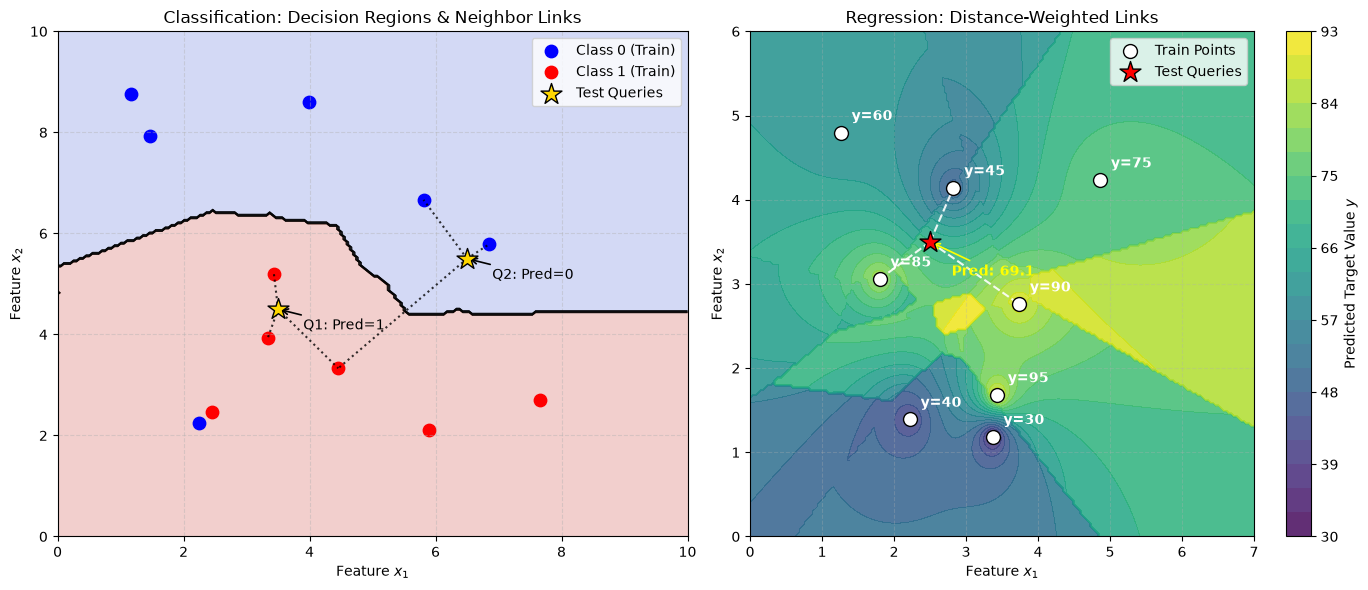

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

# --- 1. SIMULATED TOY DATA SETUP ---
np.random.seed(42)

# Classification Data
X_class_train = np.random.uniform(1, 9, (12, 2))
y_class_train = np.array([0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
X_class_test = np.array([[3.5, 4.5], [6.5, 5.5]])

# Regression Data
X_reg_train = np.random.uniform(1, 5, (8, 2))
y_reg_train = np.array([45, 85, 30, 95, 60, 75, 40, 90])
X_reg_test = np.array([[2.5, 3.5]])

# --- 2. MINIMAL CUSTOM KNN CLASS FOR PREDICTION ---
class KNearestNeighbors:
    def __init__(self, k=3, task='classification', weights='uniform'):
        self.k = k
        self.task = task
        self.weights = weights
        
    def fit(self, X, y):
        self.X_train = X
        self.y_train = y
        return self

    def predict(self, X_test):
        distances = cdist(X_test, self.X_train)
        predictions = []
        for dist_row in distances:
            idx = np.argsort(dist_row)[:self.k]
            k_labels = self.y_train[idx]
            if self.task == 'classification':
                predictions.append(1 if np.sum(k_labels) > self.k / 2 else 0)
            else: # Regression
                if self.weights == 'distance':
                    w = 1.0 / (dist_row[idx] + 1e-5)
                    predictions.append(np.sum(w * k_labels) / np.sum(w))
                else:
                    predictions.append(np.mean(k_labels))
        return np.array(predictions)

# --- 3. PLOTTING ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
k_val = 3

# 1. Classification Boundary Plot
clf = KNearestNeighbors(k=k_val, task='classification', weights='uniform').fit(X_class_train, y_class_train)
xx_c, yy_c = np.meshgrid(np.linspace(0, 10, 200), np.linspace(0, 10, 200))
Z_c = clf.predict(np.c_[xx_c.ravel(), yy_c.ravel()]).reshape(xx_c.shape)

ax1.contourf(xx_c, yy_c, Z_c, alpha=0.25, cmap='coolwarm')
ax1.contour(xx_c, yy_c, Z_c, colors='k', linewidths=0.5)

# Scatter training data
ax1.scatter(X_class_train[y_class_train == 0, 0], X_class_train[y_class_train == 0, 1], c='blue', s=80, label='Class 0 (Train)')
ax1.scatter(X_class_train[y_class_train == 1, 0], X_class_train[y_class_train == 1, 1], c='red', s=80, label='Class 1 (Train)')

# Scatter query test points
preds_c = clf.predict(X_class_test)
ax1.scatter(X_class_test[:, 0], X_class_test[:, 1], c='gold', marker='*', s=250, edgecolor='black', zorder=5, label='Test Queries')

# --- VISUAL INTERACTION LINES (CLASSIFICATION) ---
for pt in X_class_test:
    # Find indices of the k nearest neighbors
    dists = np.linalg.norm(X_class_train - pt, axis=1)
    nearest_neighbors_idx = np.argsort(dists)[:k_val]
    
    # Draw interactive connection line to each neighbor
    for idx in nearest_neighbors_idx:
        ax1.plot([pt[0], X_class_train[idx, 0]], [pt[1], X_class_train[idx, 1]], 
                 color='black', linestyle=':', linewidth=1.5, alpha=0.8, zorder=3)

for i, pt in enumerate(X_class_test):
    ax1.annotate(f'Q{i+1}: Pred={preds_c[i]}', (pt[0], pt[1]), xytext=(pt[0] + 0.4, pt[1] - 0.4),
                 arrowprops=dict(arrowstyle="->", lw=1.2))

ax1.set_title('Classification: Decision Regions & Neighbor Links')
ax1.set_xlabel('Feature $x_1$')
ax1.set_ylabel('Feature $x_2$')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.4)

# 2. Regression Prediction Surface Plot
reg = KNearestNeighbors(k=k_val, task='regression', weights='distance').fit(X_reg_train, y_reg_train)
xx_r, yy_r = np.meshgrid(np.linspace(0, 7, 200), np.linspace(0, 6, 200))
Z_r = reg.predict(np.c_[xx_r.ravel(), yy_r.ravel()]).reshape(xx_r.shape)

cntr = ax2.contourf(xx_r, yy_r, Z_r, levels=20, cmap='viridis', alpha=0.85)
fig.colorbar(cntr, ax=ax2, label='Predicted Target Value $y$')

# Scatter training points
ax2.scatter(X_reg_train[:, 0], X_reg_train[:, 1], c='white', edgecolor='black', s=100, zorder=4, label='Train Points')
for i, pt in enumerate(X_reg_train):
    ax2.annotate(f'y={y_reg_train[i]:.0f}', (pt[0], pt[1]), xytext=(pt[0] + 0.15, pt[1] + 0.15), color='white', weight='bold')

# Scatter regression queries
preds_r = reg.predict(X_reg_test)
ax2.scatter(X_reg_test[:, 0], X_reg_test[:, 1], c='red', marker='*', s=250, edgecolor='black', zorder=5, label='Test Queries')

# --- VISUAL INTERACTION LINES (REGRESSION) ---
for pt in X_reg_test:
    dists = np.linalg.norm(X_reg_train - pt, axis=1)
    nearest_neighbors_idx = np.argsort(dists)[:k_val]
    
    # Draw interactive connection line to each neighbor
    for idx in nearest_neighbors_idx:
        ax2.plot([pt[0], X_reg_train[idx, 0]], [pt[1], X_reg_train[idx, 1]], 
                 color='white', linestyle='--', linewidth=1.5, alpha=0.9, zorder=3)

for i, pt in enumerate(X_reg_test):
    ax2.annotate(f'Pred: {preds_r[i]:.1f}', (pt[0], pt[1]), xytext=(pt[0] + 0.3, pt[1] - 0.4),
                 color='yellow', weight='bold', arrowprops=dict(arrowstyle="->", color='yellow', lw=1.2))

ax2.set_title('Regression: Distance-Weighted Links')
ax2.set_xlabel('Feature $x_1$')
ax2.set_ylabel('Feature $x_2$')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


# Notes

- Feature Scaling is mendatory for K-NN. (Standard Scaler or MinMaxScaler)
- Select the Right K-Value:
    - If K is too small (e.g. k=1) then model will overfit.
    - If K is too large (e.g. K=100) then model will underfit.
    - Always  use an Odd number for K in binary classification to completely avoid 50/50 tie votes.

- It is called a "Lazzy Learner"